# Fetchig Bonds data from https://www.worldgovernmentbonds.com/country/india/

In [2]:
%run Bond_data.ipynb

C:\Users\Aditee\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\Aditee\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


In [3]:
df = get_bond_data('https://www.worldgovernmentbonds.com/country/india/', "html.parser", "w3-table money pd44 -f15")

# Processing the extracted data


In [4]:
test = df['Annualized Yield', 'Chg 1M'].str.split(" ", expand=True)
new = test[0].astype(float)*0.01
new2 = df['Annualized Yield', 'Last'].str.rstrip("%").astype(float) - new #OR can use .strip[:-1]


In [5]:
def calculate_value(ind_start, ind_stop, main_colindx):
    new_df = pd.DataFrame()
    for col in df.iloc[:,ind_start:ind_stop]:
        #print(col)
        new_df["Current"] = df.iloc[:,main_colindx].str.rstrip("%").astype(float)
        temp = df[col].str.split(" ", expand= True).dropna()
        temp2 = temp[0].astype(float)*0.01
        new_df[f'{col}' + "Yeild"] = (new_df["Current"] - temp2)
        #new_df[f'{col}' + "Yeild"] = new_df[f'{col}' + "Yeild"].astype(str).add("%")
        #new_df = pd.concat([new_df,temp3[col]], axis =1)
    return new_df

Yeilds = calculate_value(1,4,0)


Yeilds

,Current,"('Annualized Yield', 'Chg 1M')Yeild","('Annualized Yield', 'Chg 6M')Yeild","('Annualized Yield', 'Chg 12M')Yeild"
ResidualMaturity,,,,
3 months,6.778,6.642,6.830,6.900
6 months,6.795,6.763,6.930,7.090
1 year,6.845,6.710,6.936,7.110
2 years,6.849,6.640,6.949,7.080
3 years,6.845,6.871,6.977,7.084
4 years,6.855,6.870,7.003,7.084
5 years,6.863,6.877,7.022,7.065
6 years,6.858,6.867,6.993,7.138
7 years,6.942,6.932,7.038,7.093


In [6]:
import matplotlib.pyplot as plt
from mplcursors import cursor
import mpld3
import math

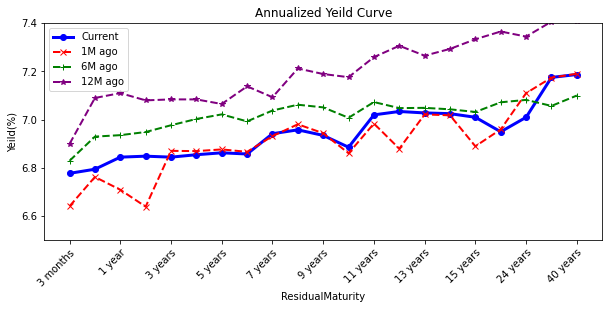

In [7]:
fig, ax = plt.subplots(figsize = (10,4))
ax.plot(Yeilds.index.to_numpy(), Yeilds['Current'].to_numpy(),color='blue', linewidth=3,marker = 'o', label = "Current")
ax.plot(Yeilds.index.to_numpy(), Yeilds.iloc[:,1].to_numpy(), color = 'red', linewidth = 2, linestyle ='--',marker = 'x', label = "1M ago")
ax.plot(Yeilds.index.to_numpy(), Yeilds.iloc[:,2].to_numpy(),color = 'green', linewidth = 2, linestyle ='--',marker = '+', label = "6M ago")
ax.plot(Yeilds.index.to_numpy(), Yeilds.iloc[:,3].to_numpy(), color = 'purple',linewidth = 2, linestyle = '--',marker = '*', label = "12M ago")
ax.set_title('Annualized Yeild Curve')
ax.set_xlabel(Yeilds.index.name)
ax.set_ylabel("Yeild(%)")
ax.set_ylim([6.5, 7.4])
ax.set_xticks(np.arange(len(Yeilds.index), step = 2))
ax.legend()
plt.setp(ax.get_xticklabels(), rotation=45, ha="right",rotation_mode="anchor")

plt.show()

# Bootstraping Zero coupon Price data to get Zero Curve

In [19]:
#conevrting index in String to years
period = []
for  i in df.index:  
    #print(i)
    temp = i.split(" ")
    if temp[1].lower() == "Months".lower() or temp[1].lower() == "Month".lower():
        period.append(int(temp[0])/12)
    elif temp[1].lower() == "Years".lower() or temp[1].lower() == "Year".lower():
        period.append(int(temp[0])*1)
#print(period)

bootstrap_data = pd.DataFrame([period,df.iloc[:,4]] ).T
bootstrap_data.columns = ["Bond Maturity", "Market Price"]
bootstrap_data



,Bond Maturity,Market Price
0,0.25,98.37
1,0.5,96.77
2,1,93.59
3,2,87.59
4,3,81.99
5,4,76.70
6,5,71.76
7,6,67.17
8,7,62.51
9,8,58.38


In [13]:
def ZeroRates(FV):
    return round((1/bootstrap_data["Bond Maturity"].astype(float))*np.log(FV/bootstrap_data["Market Price"].astype(float))*100,3)
    #return bootstrap_data
bootstrap_data["Zero Rates"]  = ZeroRates(100.0) 
bootstrap_data

,Bond Maturity,Market Price,Zero Rates
0,0.25,98.37,6.574
1,0.5,96.77,6.567
2,1,93.59,6.625
3,2,87.59,6.625
4,3,81.99,6.619
5,4,76.70,6.632
6,5,71.76,6.637
7,6,67.17,6.632
8,7,62.51,6.712
9,8,58.38,6.727


In [14]:
from scipy.interpolate import CubicSpline,interp1d 
x = np.arange(0.25,41,0.75) #points on which to calculate the interpolation

rnew = CubicSpline(bootstrap_data["Bond Maturity"].to_numpy(),bootstrap_data["Zero Rates"].to_numpy()) #Calculating the function

rold = interp1d(bootstrap_data["Bond Maturity"].to_numpy(),bootstrap_data["Zero Rates"].to_numpy(),bounds_error=False)#Calculating the function
#print(f"{x} asd {rnew(x)}")

C:\Users\Aditee\anaconda3\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


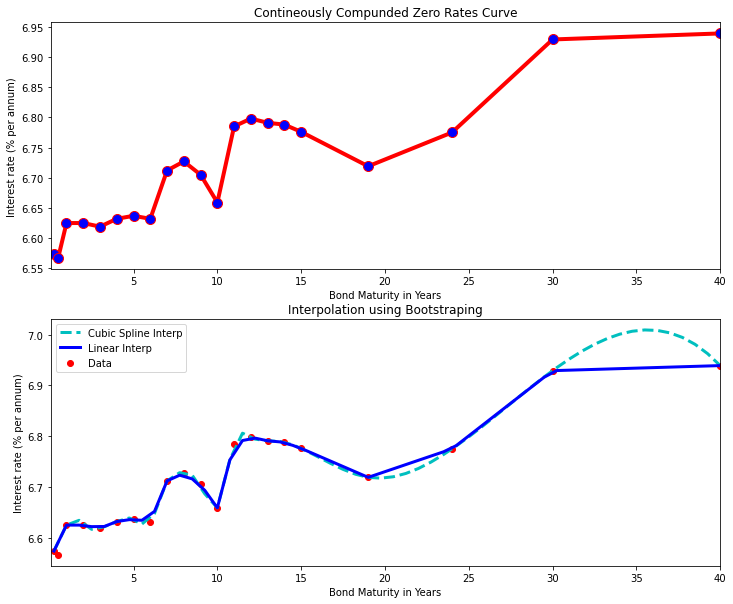

In [15]:
fig, ax  = plt.subplots(2,figsize = (12,10))
ax[0].plot(bootstrap_data["Bond Maturity"].to_numpy(),bootstrap_data["Zero Rates"].to_numpy(),color='red', linewidth=4,marker = 'o',
         markerfacecolor = 'blue', markersize = 10)

ax[0].set_title("Contineously Compunded Zero Rates Curve")
ax[0].set_xlabel("Bond Maturity in Years")
ax[0].set_xlim([0.05, 40])
ax[0].set_ylabel("Interest rate (% per annum)")

ax[1].scatter(bootstrap_data["Bond Maturity"].to_numpy(),bootstrap_data["Zero Rates"].to_numpy(),color='r', label = "Data")
ax[1].plot(x, rnew(x),color='c', linewidth=3, linestyle="--",label = "Cubic Spline Interp")
ax[1].plot(x, rold(x),color='b', linewidth=3,label = "Linear Interp")

ax[1].set_title("Interpolation using Bootstraping")
ax[1].set_xlabel("Bond Maturity in Years")
ax[1].set_xlim([0.05, 40])
ax[1].set_ylabel("Interest rate (% per annum)")
ax[1].legend()
plt.show()

# Forwards Rate Calculation

In [16]:
num = ((bootstrap_data["Zero Rates"]*bootstrap_data["Bond Maturity"]) - (bootstrap_data["Zero Rates"].shift()*bootstrap_data["Bond Maturity"].shift())).dropna()
den = (bootstrap_data["Bond Maturity"] - bootstrap_data["Bond Maturity"].shift()).dropna()

bootstrap_data['Forward Rates'] = num/den
bootstrap_data


,Bond Maturity,Market Price,Zero Rates,Forward Rates
0,0.25,98.37,6.574,NaN
1,0.5,96.77,6.567,6.56
2,1,93.59,6.625,6.683
3,2,87.59,6.625,6.625
4,3,81.99,6.619,6.607
5,4,76.70,6.632,6.671
6,5,71.76,6.637,6.657
7,6,67.17,6.632,6.607
8,7,62.51,6.712,7.192
9,8,58.38,6.727,6.832


In [17]:
bootstrap_data["Predicted if (Forward > Zero)"] = np.where(bootstrap_data["Zero Rates"]>=bootstrap_data["Zero Rates"].shift(), "True","False")
bootstrap_data

,Bond Maturity,Market Price,Zero Rates,Forward Rates,Predicted if (Forward > Zero)
0,0.25,98.37,6.574,NaN,False
1,0.5,96.77,6.567,6.56,False
2,1,93.59,6.625,6.683,True
3,2,87.59,6.625,6.625,True
4,3,81.99,6.619,6.607,False
5,4,76.70,6.632,6.671,True
6,5,71.76,6.637,6.657,True
7,6,67.17,6.632,6.607,False
8,7,62.51,6.712,7.192,True
9,8,58.38,6.727,6.832,True


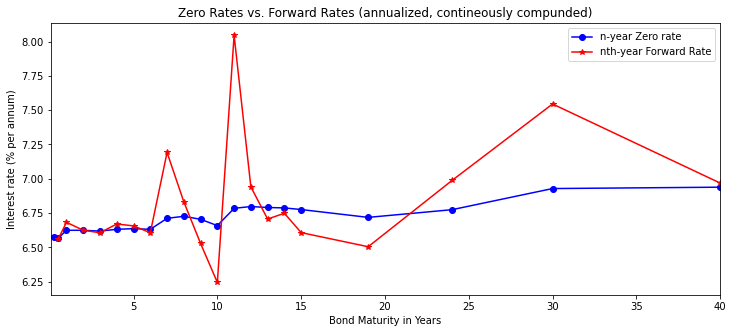

In [18]:
fig, ax = plt.subplots(figsize =(12,5))
ax.plot(bootstrap_data["Bond Maturity"].to_numpy(), bootstrap_data["Zero Rates"].to_numpy(), color = 'blue', marker = "o", label = "n-year Zero rate")
ax.plot(bootstrap_data["Bond Maturity"].to_numpy(),bootstrap_data['Forward Rates'].to_numpy(),color="r", marker = '*', label = "nth-year Forward Rate")

ax.set_title("Zero Rates vs. Forward Rates (annualized, contineously compunded)")
ax.set_xlabel("Bond Maturity in Years")
ax.set_xlim([0.05, 40])
ax.set_ylabel("Interest rate (% per annum)")
ax.legend()
plt.show()